In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import re
import glob
import logging
from multiprocessing import Pool, cpu_count
from loguru import logger
from sklearn.neighbors import NearestNeighbors


In [104]:
# Define the path to synchronized data directory
script_dir = os.path.dirname(os.path.abspath('__file__'))
filtered_dir = os.path.join(script_dir, '..', '..', 'filtered')
metadata_dir = os.path.join(script_dir, '..', '..', 'metadata')

In [105]:
df = pd.read_csv(filtered_dir + "/filtered.csv", parse_dates=["utc_timestamp"], low_memory=False, date_format='ISO8601')


In [106]:
df.head()

,utc_timestamp,seg_id,actual_voyage_id (calculated),temporary_voyage_id (calculated),voyage_duration_hours (calculated),Vessel Hull Over Ground Speed (knots),Vessel Hull Through Water Longitudinal Speed (knots),cumulative_fouling_penalty_index (calculated),Vessel External Conditions Wind Relative Speed (knots),Vessel External Conditions Wind Relative Angle (degrees),...,Imputed Spike in Vessel Hull Heading True Angle,Imputed Spike in Main Engine Turbocharger Rotational Speed,Imputed Spike in Vessel Hull Through Water Longitudinal Speed,Imputed Spike in Main Engine Fuel Oil Inlet Mass Flow,Imputed Spike in Vessel Propeller Shaft Mechanical Power,Imputed Spike in Vessel Propeller Shaft Rotational Speed,Imputed Spike in Vessel Propeller Shaft Torque,Imputed Spike in Vessel Propeller Shaft Thrust Force,Imputed Spike in Main Engine Fuel Load %,Imputed Spike in Main Engine Scavenging Air Pressure
0,2024-01-04 08:05:00.003000+00:00,11,1.0,1.0,1.409380,12.748889,12.200,NaN,14.900,328.50,...,0,0,0,0,0,0,0,0,0,0
1,2024-01-04 08:05:15.003000+00:00,11,1.0,1.0,1.414588,12.717778,12.100,NaN,13.800,325.50,...,0,0,0,0,0,0,0,0,0,0
2,2024-01-04 08:05:30.003000+00:00,11,1.0,1.0,1.417713,12.686667,11.975,NaN,13.350,326.00,...,0,0,0,0,0,0,0,0,0,0
3,2024-01-04 08:05:45.003000+00:00,11,1.0,1.0,1.421880,12.655556,11.875,NaN,12.325,329.75,...,0,0,0,0,0,0,0,0,0,0
4,2024-01-04 08:06:00.003000+00:00,11,1.0,1.0,1.427088,12.624444,11.750,NaN,12.000,326.00,...,0,0,0,0,0,0,0,0,0,0


In [107]:
df.columns

Index(['utc_timestamp', 'seg_id', 'actual_voyage_id (calculated)',
       'temporary_voyage_id (calculated)',
       'voyage_duration_hours (calculated)',
       'Vessel Hull Over Ground Speed (knots)',
       'Vessel Hull Through Water Longitudinal Speed (knots)',
       'cumulative_fouling_penalty_index (calculated)',
       'Vessel External Conditions Wind Relative Speed (knots)',
       'Vessel External Conditions Wind Relative Angle (degrees)',
       'delta_fouling_penalty_index (calculated)',
       'Vessel Hull Heading True Angle (degrees)',
       'Vessel Hull Heading Turn Rate (deg/min)',
       'Main Engine Scavenging Air Pressure (bar)',
       'Main Engine Fuel Load % (%)',
       'Main Engine Turbocharger Rotational Speed (rpm)',
       'Main Engine Rotational Speed (rpm)',
       'Vessel Propeller Shaft Revolutions (cumulative) (revs)',
       'Vessel Propeller Shaft Rotational Speed (rpm)',
       'Main Engine Fuel Oil Inlet Mass Flow (kg/hr)',
       'Vessel Propeller 

In [108]:
sys.path.append('..')  # points to the cleaning-scripts/ folder

from config import TORQUEMETER_CALIBRATION_DATE


In [109]:
# ensure date time in the utc times

# 2. Correlation validations

def correlation_check(
    df_synced: pd.DataFrame,
    column_name_x: str,
    column_name_y: str,
    line_graph_start,
    line_graph_end,
    mean_ratio: bool = False,
    # --- Speed filter ---
    min_speed: float = 0.0,
    speed_column: str | None = None,   # if None, auto-pick STW then SOG
    stw_qid: str = DEFAULT_STW_QID,
    sog_qid: str = DEFAULT_SOG_QID,
    # --- Metadata for pretty naming ---
    metadata: pd.DataFrame | str | None = None,  # DataFrame or CSV path
    metadata_qid_col: str = "qid_mapping",
    metadata_quantity_col: str = "quantity_name",
    metadata_source_col: str = "source_name",
    metadata_unit_col: str = "unit",
    # --- Plot tuning ---
    scatter_s: float = 1,
    scatter_alpha: float = 0.03,
    # --- Line plot indexing (ONLY affects the line plot panel) ---
    line_index: bool = True,
    line_index_mode: str = "base100",  # "base100" | "minmax" | "zscore"
):
    """
    Output:
      - Matplotlib figure with two side-by-side plots:
          (1) scatter: x vs y using ALL rows (after optional speed filter)
              + trendline + stats box (r, N, fit, mean-ratio)
          (2) line plot: x and y vs time within [line_graph_start, line_graph_end]
              (after optional speed filter), optionally indexed for comparability
      - Returns: (fig, (ax_scatter, ax_line))

    Notes:
      - min_speed filter uses `speed_column` if provided; else prefers STW then SOG.
      - QID->label lookup triggers only if ':' is in the column name (your requirement).
      - Line indexing is applied ONLY to the line plot (panel 2), scatter stays raw units.
    """

    # ---- Basic checks ----
    if column_name_x not in df_synced.columns:
        raise KeyError(f"column_name_x='{column_name_x}' not in df_synced.columns")
    if column_name_y not in df_synced.columns:
        raise KeyError(f"column_name_y='{column_name_y}' not in df_synced.columns")

    # ---- Load/prepare metadata mapping ----
    meta_map = None
    if metadata is not None:
        meta_df = pd.read_csv(metadata) if isinstance(metadata, str) else metadata

        needed = {metadata_qid_col, metadata_quantity_col, metadata_source_col, metadata_unit_col}
        missing = needed - set(meta_df.columns)
        if missing:
            raise ValueError(
                f"metadata is missing columns: {sorted(missing)}. "
                f"Got: {list(meta_df.columns)}"
            )

        meta_df = meta_df.copy()
        meta_df[metadata_qid_col] = meta_df[metadata_qid_col].astype(str).str.strip()

        meta_map = meta_df.set_index(metadata_qid_col)[
            [metadata_quantity_col, metadata_source_col, metadata_unit_col]
        ].to_dict(orient="index")

    # Token pattern: grabs chunks like "2::0::6::1_1::1::0::2::0_1::0::1::0_8"
    token_pattern = re.compile(r"[0-9:]+(?:_[0-9:]+)*")

    def _clean_unit(u: str) -> str:
        return str(u).replace("Â", "").strip()

    def _extract_qid(col: str) -> str | None:
        if meta_map is None:
            return None
        c = str(col).strip()
        if c in meta_map:
            return c

        # Try to extract a token that matches a metadata key
        for m in token_pattern.finditer(c):
            tok = m.group(0)
            if "::" in tok and tok in meta_map:
                return tok
        return None

    def _pretty_label(col: str) -> str:
        c = str(col).strip()

        # Only trigger lookup if ':' is present (your requirement)
        if ":" not in c or meta_map is None:
            return c

        qid = _extract_qid(c)
        if qid is None:
            return c

        rec = meta_map[qid]
        qname = str(rec.get(metadata_quantity_col, "")).strip()
        sname = str(rec.get(metadata_source_col, "")).strip()
        unit = _clean_unit(rec.get(metadata_unit_col, ""))

        if unit:
            return f"{qname} ({sname}) [{unit}]"
        return f"{qname} ({sname})"

    label_x = _pretty_label(column_name_x)
    label_y = _pretty_label(column_name_y)

    # ---- Min speed filtering ----
    df_plot = df_synced
    if min_speed is None:
        min_speed = 0.0
    min_speed = float(min_speed)

    if min_speed > 0.0:
        if speed_column is None:
            if stw_qid in df_plot.columns:
                speed_column = stw_qid
            elif sog_qid in df_plot.columns:
                speed_column = sog_qid
            else:
                raise KeyError(
                    "min_speed > 0 but no speed_column provided and neither default STW nor SOG QID exists in df_synced."
                )
        if speed_column not in df_plot.columns:
            raise KeyError(f"speed_column='{speed_column}' not in df_synced.columns")

        speed_vals = pd.to_numeric(df_plot[speed_column], errors="coerce")
        df_plot = df_plot.loc[speed_vals >= min_speed].copy()

    # ---- Scatter data (ALL rows, ignoring time) ----
    x = pd.to_numeric(df_plot[column_name_x], errors="coerce")
    y = pd.to_numeric(df_plot[column_name_y], errors="coerce")
    mask_xy = x.notna() & y.notna()

    x_vals = x[mask_xy].to_numpy(dtype="float64", copy=False)
    y_vals = y[mask_xy].to_numpy(dtype="float64", copy=False)
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_vals = x_vals[mask_finite]
    y_vals = y_vals[mask_finite]
    n = int(x_vals.size)

    ratio = None
    if mean_ratio:
        mean_x = float(np.mean(x_vals)) if n else float("nan")
        mean_y = float(np.mean(y_vals)) if n else float("nan")
        ratio = (mean_x / mean_y) if (np.isfinite(mean_y) and mean_y != 0.0) else float("nan")
        print(f"Mean ratio (mean({column_name_x}) / mean({column_name_y})) = {ratio:.6g}")

    r = float("nan")
    if n >= 2:
        sx = float(np.std(x_vals))
        sy = float(np.std(y_vals))
        if sx > 0 and sy > 0:
            r = float(np.corrcoef(x_vals, y_vals)[0, 1])

    slope = float("nan")
    intercept = float("nan")
    if n >= 2:
        x_mean = float(np.mean(x_vals))
        y_mean = float(np.mean(y_vals))
        x_var = float(np.mean((x_vals - x_mean) ** 2))
        if x_var > 0:
            cov_xy = float(np.mean((x_vals - x_mean) * (y_vals - y_mean)))
            slope = cov_xy / x_var
            intercept = y_mean - slope * x_mean

    # ---- Line-plot data (time window) ----
    start = pd.to_datetime(line_graph_start)
    end = pd.to_datetime(line_graph_end)
    if start > end:
        raise ValueError("line_graph_start must be <= line_graph_end")

    if isinstance(df_plot.index, pd.DatetimeIndex):
        df_time = df_plot.sort_index().loc[start:end, [column_name_x, column_name_y]]
        time_index = df_time.index
    elif "utc_timestamp" in df_plot.columns or "timestamp" in df_plot.columns:
        ts_col = "utc_timestamp" if "utc_timestamp" in df_plot.columns else "timestamp"
        ts = pd.to_datetime(df_plot[ts_col])
        df_tmp = df_plot.assign(_ts=ts).sort_values("_ts")
        df_time = df_tmp[(df_tmp["_ts"] >= start) & (df_tmp["_ts"] <= end)][["_ts", column_name_x, column_name_y]]
        time_index = df_time["_ts"]
    else:
        raise ValueError("df_synced must have a DatetimeIndex or a 'utc_timestamp'/'timestamp' column for the line plot.")

    # ---- Line indexing helper (applies ONLY to panel 2) ----
    def _index_series(s: pd.Series, mode: str) -> np.ndarray:
        s = pd.to_numeric(s, errors="coerce").astype("float64")

        if mode == "zscore":
            arr = s.to_numpy()
            mu = float(np.nanmean(arr))
            sd = float(np.nanstd(arr))
            if np.isfinite(sd) and sd > 0:
                return ((s - mu) / sd).to_numpy()
            return np.full(len(s), np.nan)

        if mode == "minmax":
            arr = s.to_numpy()
            a = float(np.nanmin(arr))
            b = float(np.nanmax(arr))
            if np.isfinite(a) and np.isfinite(b) and b > a:
                return ((s - a) / (b - a)).to_numpy()
            return np.full(len(s), np.nan)

        # default: base100
        valid = s[np.isfinite(s)]
        if valid.empty:
            return np.full(len(s), np.nan)
        base = float(valid.iloc[0])
        if np.isfinite(base) and base != 0.0:
            return (s / base * 100.0).to_numpy()
        return np.full(len(s), np.nan)

    # ---- Prepare line-series values ----
    if line_index:
        x_line_vals = _index_series(df_time[column_name_x], line_index_mode)
        y_line_vals = _index_series(df_time[column_name_y], line_index_mode)
        label_x_line = f"{label_x} (indexed)"
        label_y_line = f"{label_y} (indexed)"
        ylab = "Indexed value"
    else:
        x_line_vals = pd.to_numeric(df_time[column_name_x], errors="coerce").to_numpy()
        y_line_vals = pd.to_numeric(df_time[column_name_y], errors="coerce").to_numpy()
        label_x_line = label_x
        label_y_line = label_y
        ylab = ""

    # ---- Plotting ----
    fig, (ax_scatter, ax_line) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    ax_scatter.scatter(
        x_vals, y_vals,
        s=scatter_s, alpha=scatter_alpha, marker=".", linewidths=0,
        rasterized=True,
    )
    ax_scatter.set_xlabel(label_x)
    ax_scatter.set_ylabel(label_y)
    ax_scatter.set_title(f"Scatter (min speed: {min_speed:g})" if min_speed > 0 else "Scatter (all rows)")

    if np.isfinite(slope) and np.isfinite(intercept) and n >= 2:
        if n >= 100:
            x1, x2 = np.quantile(x_vals, [0.01, 0.99])
        else:
            x1, x2 = float(np.min(x_vals)), float(np.max(x_vals))
        x_fit = np.array([x1, x2], dtype="float64")
        y_fit = intercept + slope * x_fit
        ax_scatter.plot(x_fit, y_fit, linewidth=2.0, color="tab:orange", alpha=0.9)

    stats_lines = [
        f"N = {n:,}",
        f"Pearson r = {r:.3f}" if np.isfinite(r) else "Pearson r = NaN",
        f"Fit: y = {slope:.4g}x + {intercept:.4g}" if (np.isfinite(slope) and np.isfinite(intercept)) else "Fit: NaN",
    ]
    if mean_ratio:
        stats_lines.append(
            f"Mean ratio = {ratio:.4g}" if (ratio is not None and np.isfinite(ratio)) else "Mean ratio = NaN"
        )

    ax_scatter.text(
        0.02, 0.98, "\n".join(stats_lines),
        transform=ax_scatter.transAxes,
        va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.3", alpha=0.85),
    )

    ax_line.plot(time_index, x_line_vals, label=label_x_line, linewidth=0.8)
    ax_line.plot(time_index, y_line_vals, label=label_y_line, linewidth=0.8)
    ax_line.set_xlabel("Time")
    if ylab:
        ax_line.set_ylabel(ylab)
    suffix = f" (indexed: {line_index_mode})" if line_index else ""
    ax_line.set_title(f"Time window: {start} to {end}{suffix}")
    ax_line.legend()

    return fig, (ax_scatter, ax_line)


# 3. Torquemeter recalibration


In [110]:

TORQUEMETER_CALIBRATION_DATE = "2024-07-01"

fuel_load_col = "Main Engine Fuel Load % (%)"
power_col = "Vessel Propeller Shaft Mechanical Power (KW)"
torque_col = "Vessel Propeller Shaft Torque (N*m)"
shaft_rpm_col = "Vessel Propeller Shaft Rotational Speed (rpm)"

def recompute_shaft_power_from_torque_and_rpm(torque_nm, shaft_rpm):
    """
    Compute shaft mechanical power in kW from:
    - torque in Nm
    - shaft rotational speed in rpm

    P[W] = torque * omega
    omega = 2*pi*rpm/60

    Therefore:
    P[kW] = torque_nm * (2*pi*shaft_rpm/60) / 1000
    """
    return torque_nm * (2 * np.pi * shaft_rpm / 60.0) / 1000.0

def plot_fuel_load_vs_power_by_calibration_date(
    df,
    calibration_date=TORQUEMETER_CALIBRATION_DATE,
    timestamp_col="utc_timestamp",
    fuel_load_col=fuel_load_col,
    power_col=power_col,
    figsize=(10, 6),
    alpha=0.5,
    s=12,
):
    df = df.copy()

    before_calibration_key = f"Before calibration ({calibration_date})"
    after_calibration_key = f"After calibration ({calibration_date})"

    required_cols = [timestamp_col, fuel_load_col, power_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")
    if df[timestamp_col].isna().any():
        logger.warning("Some timestamps could not be parsed and were set to NaT.")

    calibration_date = pd.Timestamp(calibration_date, tz="UTC")

    df["torquemeter_period"] = pd.NA
    df.loc[df[timestamp_col] < calibration_date, "torquemeter_period"] = before_calibration_key
    df.loc[df[timestamp_col] >= calibration_date, "torquemeter_period"] = after_calibration_key

    plot_df = df[[timestamp_col, fuel_load_col, power_col, "torquemeter_period"]].dropna()

    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=plot_df,
        x=fuel_load_col,
        y=power_col,
        hue="torquemeter_period",
        palette={before_calibration_key: "tab:blue", after_calibration_key: "tab:orange"},
        alpha=alpha,
        s=s,
        ax=ax,
    )

    ax.set_title("Main Engine Fuel Load vs Shaft Power")
    ax.set_xlabel("Main Engine Fuel Load (%)")
    ax.set_ylabel("Vessel Propeller Shaft Mechanical Power (kW)")
    ax.legend(title="")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    return fig, ax, df

def prepare_pre_post_data(
    df,
    calibration_date=TORQUEMETER_CALIBRATION_DATE,
    timestamp_col="utc_timestamp",
    fuel_load_col=fuel_load_col,
    power_col=power_col,
    torque_col=torque_col,
    shaft_rpm_col=shaft_rpm_col,
):
    df = df.copy()

    required_cols = [timestamp_col, fuel_load_col, power_col, torque_col, shaft_rpm_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")
    calibration_date = pd.Timestamp(calibration_date, tz="UTC")

    df = df.dropna(subset=[timestamp_col, fuel_load_col, power_col, torque_col, shaft_rpm_col]).copy()
    df["torquemeter_period"] = np.where(
        df[timestamp_col] < calibration_date,
        "pre",
        "post"
    )

    pre_df = df.loc[df["torquemeter_period"] == "pre"].copy()
    post_df = df.loc[df["torquemeter_period"] == "post"].copy()

    if pre_df.empty or post_df.empty:
        raise ValueError("Need both pre- and post-calibration observations.")

    return pre_df, post_df

def _aggregate_neighbor_power(neighbor_power, agg="median"):
    if agg == "median":
        return np.median(neighbor_power, axis=1)
    if agg == "mean":
        return np.mean(neighbor_power, axis=1)
    raise ValueError("agg must be 'median' or 'mean'")

def _compute_loss(y_true, y_ref, loss="medae"):
    diff = y_true - y_ref

    if loss == "medae":
        return np.median(np.abs(diff))
    if loss == "mae":
        return np.mean(np.abs(diff))
    if loss == "rmse":
        return np.sqrt(np.mean(diff ** 2))

    raise ValueError("loss must be 'medae', 'mae', or 'rmse'")

def evaluate_single_k_and_torque_offset(
    pre_df,
    post_df,
    k,
    torque_offset_nm,
    fuel_load_col=fuel_load_col,
    power_col=power_col,
    torque_col=torque_col,
    shaft_rpm_col=shaft_rpm_col,
    neighbor_agg="median",
    loss="medae",
    max_fuel_load_distance=None,
):
    k_eff = min(int(k), len(pre_df))
    if k_eff < 1:
        raise ValueError("k must be at least 1")

    X_pre = pre_df[[fuel_load_col]].to_numpy()
    X_post = post_df[[fuel_load_col]].to_numpy()

    y_pre = pre_df[power_col].to_numpy()
    post_torque = post_df[torque_col].to_numpy()
    post_rpm = post_df[shaft_rpm_col].to_numpy()

    corrected_post_torque = post_torque + torque_offset_nm
    corrected_post_power = recompute_shaft_power_from_torque_and_rpm(
        torque_nm=corrected_post_torque,
        shaft_rpm=post_rpm,
    )

    nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nn.fit(X_pre)

    distances, indices = nn.kneighbors(X_post)

    if max_fuel_load_distance is None:
        keep_mask = np.ones(len(post_df), dtype=bool)
    else:
        keep_mask = distances[:, -1] <= max_fuel_load_distance

    if keep_mask.sum() == 0:
        return {
            "k": k,
            "k_effective": k_eff,
            "torque_offset_nm": torque_offset_nm,
            "loss": np.nan,
            "n_matches": 0,
            "mean_kth_distance": np.nan,
            "median_kth_distance": np.nan,
        }

    kept_indices = indices[keep_mask]
    kept_distances = distances[keep_mask]

    neighbor_power = y_pre[kept_indices]
    matched_reference_power = _aggregate_neighbor_power(neighbor_power, agg=neighbor_agg)

    corrected_post_power_kept = corrected_post_power[keep_mask]
    current_loss = _compute_loss(corrected_post_power_kept, matched_reference_power, loss=loss)

    return {
        "k": k,
        "k_effective": k_eff,
        "torque_offset_nm": float(torque_offset_nm),
        "loss": current_loss,
        "n_matches": int(keep_mask.sum()),
        "mean_kth_distance": float(np.mean(kept_distances[:, -1])),
        "median_kth_distance": float(np.median(kept_distances[:, -1])),
    }

def tune_k_and_torque_offset(
    df,
    k_values=(1, 3, 5, 10, 20, 30, 50),
    torque_offset_grid=np.arange(-2000, 2001, 100),
    calibration_date=TORQUEMETER_CALIBRATION_DATE,
    timestamp_col="utc_timestamp",
    fuel_load_col=fuel_load_col,
    power_col=power_col,
    torque_col=torque_col,
    shaft_rpm_col=shaft_rpm_col,
    neighbor_agg="median",
    loss="medae",
    max_fuel_load_distance=None,
):
    pre_df, post_df = prepare_pre_post_data(
        df=df,
        calibration_date=calibration_date,
        timestamp_col=timestamp_col,
        fuel_load_col=fuel_load_col,
        power_col=power_col,
        torque_col=torque_col,
        shaft_rpm_col=shaft_rpm_col,
    )

    rows = []
    for k in k_values:
        for torque_offset_nm in torque_offset_grid:
            result = evaluate_single_k_and_torque_offset(
                pre_df=pre_df,
                post_df=post_df,
                k=k,
                torque_offset_nm=float(torque_offset_nm),
                fuel_load_col=fuel_load_col,
                power_col=power_col,
                torque_col=torque_col,
                shaft_rpm_col=shaft_rpm_col,
                neighbor_agg=neighbor_agg,
                loss=loss,
                max_fuel_load_distance=max_fuel_load_distance,
            )
            rows.append(result)

    all_results = pd.DataFrame(rows)

    valid_results = all_results.dropna(subset=["loss"]).copy()
    if valid_results.empty:
        raise ValueError("No valid matches found. Try relaxing max_fuel_load_distance or k_values.")

    best_per_k = (
        valid_results.sort_values(["k", "loss", "mean_kth_distance"])
        .groupby("k", as_index=False)
        .first()
        .sort_values("k")
        .reset_index(drop=True)
    )

    overall_best = best_per_k.sort_values(["loss", "mean_kth_distance"]).iloc[0].to_dict()

    return {
        "all_results": all_results,
        "best_per_k": best_per_k,
        "overall_best": overall_best,
        "pre_df": pre_df,
        "post_df": post_df,
    }

def plot_k_sensitivity(best_per_k_df, figsize=(10, 5)):
    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(best_per_k_df["k"], best_per_k_df["loss"], marker="o", color="tab:blue")
    ax1.set_xlabel("k")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        best_per_k_df["k"],
        best_per_k_df["torque_offset_nm"],
        marker="s",
        linestyle="--",
        color="tab:orange",
    )
    ax2.set_ylabel("Best torque offset (Nm)", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.title("Sensitivity of best torque-offset correction to k")
    plt.tight_layout()
    return fig, (ax1, ax2)

def apply_torque_offset_correction(
    df,
    torque_offset_nm,
    calibration_date=TORQUEMETER_CALIBRATION_DATE,
    timestamp_col="utc_timestamp",
    torque_col=torque_col,
    shaft_rpm_col=shaft_rpm_col,
    power_col=power_col,
    new_torque_col="Corrected Vessel Propeller Shaft Torque (Nm)",
    new_power_col="Corrected Vessel Propeller Shaft Mechanical Power (KW)",
    keep_original_power=True,
):
    """
    Apply an additive correction to torque after the calibration date,
    then recompute shaft power from corrected torque and observed shaft RPM.
    """

    df = df.copy()

    required_cols = [timestamp_col, torque_col, shaft_rpm_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")
    calibration_date = pd.Timestamp(calibration_date, tz="UTC")

    post_mask = df[timestamp_col] >= calibration_date

    df[new_torque_col] = df[torque_col]
    df.loc[post_mask, new_torque_col] = df.loc[post_mask, torque_col] + torque_offset_nm

    df[new_power_col] = recompute_shaft_power_from_torque_and_rpm(
        torque_nm=df[new_torque_col],
        shaft_rpm=df[shaft_rpm_col],
    )

    if keep_original_power and power_col in df.columns:
        df["Power Correction Delta (KW)"] = df[new_power_col] - df[power_col]

    return df

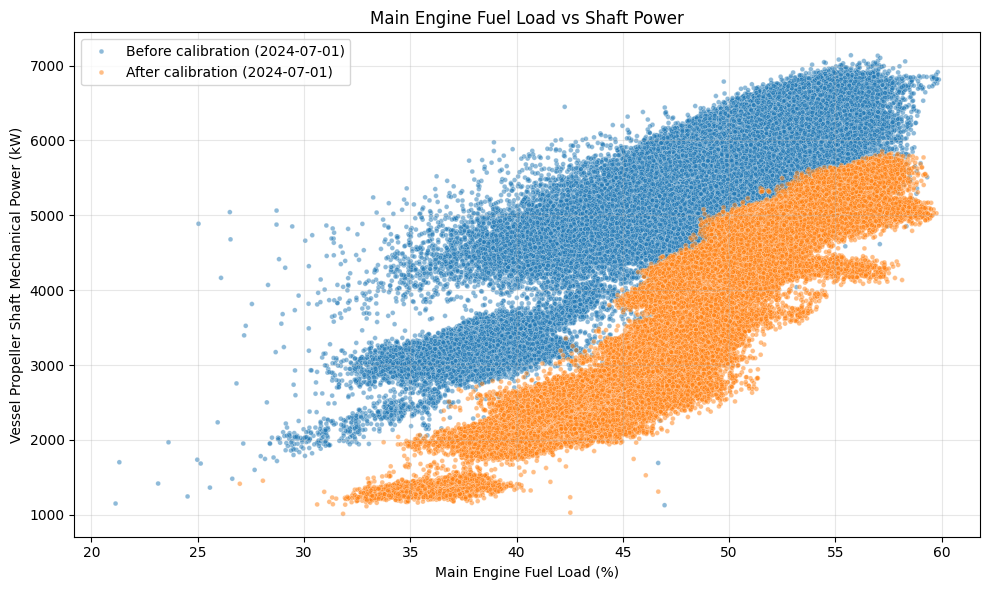

In [111]:
fig, ax, df_plot = plot_fuel_load_vs_power_by_calibration_date(df)
plt.show()

In [123]:
results = tune_k_and_torque_offset(
    df,
    k_values=[5, 10, 20, 30],
    torque_offset_grid=np.arange(150, 200, 250),
    neighbor_agg="median",
    loss="medae",
    max_fuel_load_distance=None,
)

best_per_k = results["best_per_k"]
overall_best = results["overall_best"]

print(best_per_k)
print(overall_best)

df_corrected = apply_torque_offset_correction(
    df=df,
    torque_offset_nm=overall_best["torque_offset_nm"],
)

    k  k_effective  torque_offset_nm         loss  n_matches  \
0   5            5             150.0  5318.139104     505517   
1  10           10             150.0  5327.026949     505517   
2  20           20             150.0  5344.439451     505517   
3  30           30             150.0  5356.060640     505517   

   mean_kth_distance  median_kth_distance  
0           0.000511             0.000255  
1           0.001020             0.000545  
2           0.002008             0.001145  
3           0.002963             0.001744  
{'k': 5.0, 'k_effective': 5.0, 'torque_offset_nm': 150.0, 'loss': 5318.139104486957, 'n_matches': 505517.0, 'mean_kth_distance': 0.0005111000855978792, 'median_kth_distance': 0.00025466666667028903}


In [ ]:
fig, ax, _ = plot_fuel_load_vs_power_by_calibration_date(
    df_corrected,
    power_col="Corrected Vessel Propeller Shaft Mechanical Power (KW)",
)
plt.show()